# 02 — RNNs and why they hit a wall

> *Tonight: we give the model memory. It helps. And then we see, concretely, the two things that make this approach break down — setting up the need for what comes next.*

Last night's bigram was blind past one character. The obvious fix is to let the model carry information *forward* as it reads. That's exactly what a **Recurrent Neural Network (RNN)** does — at each step it updates an internal hidden state, so by the time it reads character 100 it has in principle been influenced by all 99 before it.

We'll build a tiny RNN from scratch, train it, and then do two experiments that expose its limits:

1. **The sequential bottleneck** — RNNs can't process a sequence in parallel. Each step depends on the previous hidden state. Time scales linearly with sequence length no matter how many GPUs you throw at it.
2. **Vanishing gradients** — information from far back gets squeezed through many matrix multiplications on its way to the output. The gradient signal shrinks exponentially. The model struggles to learn long-range dependencies.

These two pains are exactly what the transformer's attention mechanism was invented to solve.


In [1]:
# --- Setup recap -----------------------------------------------------------
import sys, pathlib, math, time
ROOT = pathlib.Path.cwd().resolve()
while not (ROOT / "src" / "viz.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from src import viz
viz.style()

text = (ROOT / "data" / "tinyshakespeare.txt").read_text(encoding="utf-8")
chars = sorted(set(text))
vocab_size = len(chars)
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}
data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device={device}, vocab_size={vocab_size}")


device=cpu, vocab_size=65


## A tiny RNN, written out

The RNN is the simplest possible recurrence:

$$
\begin{aligned}
h_t &= \tanh(W_{xh}\, x_t + W_{hh}\, h_{t-1} + b_h) \\
y_t &= W_{hy}\, h_t + b_y
\end{aligned}
$$

One hidden state `h`, of fixed size, that gets updated each step from (previous hidden, current input) and re-used for the next step. The readout `y_t` is the vector of logits over the vocabulary at position `t`.

Below is the entire model — three weight matrices, two bias vectors, an input embedding. About thirty lines. Nothing is hidden behind `nn.RNN`.


In [2]:
HIDDEN = 128
EMB = 32

# Parameters
emb = torch.randn(vocab_size, EMB, device=device) * 0.5          # token embeddings
W_xh = torch.randn(EMB, HIDDEN, device=device) * (1 / math.sqrt(EMB))
W_hh = torch.randn(HIDDEN, HIDDEN, device=device) * (1 / math.sqrt(HIDDEN))
b_h  = torch.zeros(HIDDEN, device=device)
W_hy = torch.randn(HIDDEN, vocab_size, device=device) * (1 / math.sqrt(HIDDEN))
b_y  = torch.zeros(vocab_size, device=device)

for p in [emb, W_xh, W_hh, b_h, W_hy, b_y]:
    p.requires_grad_(True)

params = [emb, W_xh, W_hh, b_h, W_hy, b_y]
n_params = sum(p.numel() for p in params)
print(f"RNN parameter count: {n_params:,}")


def rnn_forward(idx, h=None):
    # idx: (B, T) long tensor of token ids.
    # Returns logits (B, T, vocab_size) and final hidden state (B, HIDDEN).
    B, T = idx.shape
    x = emb[idx]                                # (B, T, EMB)
    if h is None:
        h = torch.zeros(B, HIDDEN, device=idx.device)
    logits_all = []
    for t in range(T):
        h = torch.tanh(x[:, t] @ W_xh + h @ W_hh + b_h)
        logits_all.append(h @ W_hy + b_y)       # (B, vocab)
    logits = torch.stack(logits_all, dim=1)     # (B, T, vocab)
    return logits, h


RNN parameter count: 31,073


## Train it

We draw random windows of length `block_size` from the corpus. For every position `t` in the window the target is the next character `t+1`. Loss is averaged cross-entropy across all positions and all sequences in the batch.


In [3]:
BLOCK = 64        # how far into the past the RNN gets to see per training window
BATCH = 64
STEPS = 1500
LR = 3e-3

def get_batch(split_data, block=BLOCK, batch=BATCH):
    ix = torch.randint(0, len(split_data) - block - 1, (batch,))
    x = torch.stack([split_data[i : i + block] for i in ix]).to(device)
    y = torch.stack([split_data[i + 1 : i + block + 1] for i in ix]).to(device)
    return x, y

optimizer = torch.optim.Adam(params, lr=LR)
history = []
for step in range(STEPS):
    xb, yb = get_batch(train_data)
    logits, _ = rnn_forward(xb)
    loss = F.cross_entropy(logits.reshape(-1, vocab_size), yb.reshape(-1))
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(params, 5.0)      # RNNs love to explode. Clip.
    optimizer.step()
    history.append(loss.item())
    if (step + 1) % 300 == 0:
        print(f"step {step+1:4d} | loss {loss.item():.4f}")

# Quick validation pass.
@torch.no_grad()
def eval_loss(split_data, n_batches=20):
    losses = []
    for _ in range(n_batches):
        xb, yb = get_batch(split_data)
        logits, _ = rnn_forward(xb)
        losses.append(F.cross_entropy(logits.reshape(-1, vocab_size), yb.reshape(-1)).item())
    return float(np.mean(losses))

rnn_val_loss = eval_loss(val_data)
print(f"\nRNN val loss:           {rnn_val_loss:.4f} nats/token")
print(f"Bigram val loss (N-01): ~2.45 nats/token  <-- what we're beating")


step  300 | loss 1.8861


step  600 | loss 1.7407


step  900 | loss 1.6865


step 1200 | loss 1.7007


step 1500 | loss 1.6087

RNN val loss:           1.8113 nats/token
Bigram val loss (N-01): ~2.45 nats/token  <-- what we're beating


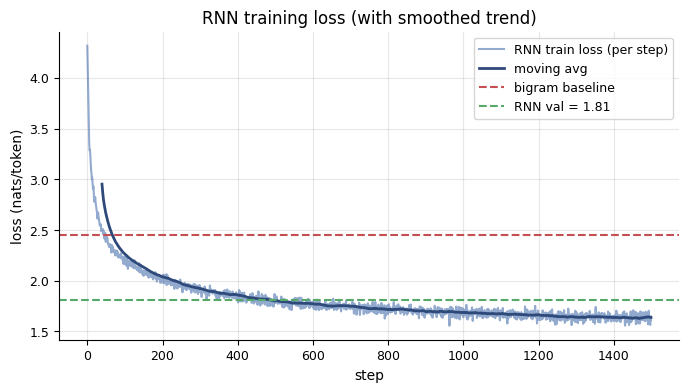

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history, alpha=0.6, color="#4C72B0", label="RNN train loss (per step)")
# running average for a smoother line
window = 40
smooth = np.convolve(history, np.ones(window)/window, mode="valid")
ax.plot(range(window-1, len(history)), smooth, color="#2E4A7A", linewidth=2, label="moving avg")
ax.axhline(2.45, color="#C44E52", linestyle="--", label="bigram baseline")
ax.axhline(rnn_val_loss, color="#55A868", linestyle="--", label=f"RNN val = {rnn_val_loss:.2f}")
ax.set_xlabel("step"); ax.set_ylabel("loss (nats/token)")
ax.set_title("RNN training loss (with smoothed trend)")
ax.legend(); ax.grid(alpha=0.3)
plt.show()


Solid improvement over the bigram baseline. The RNN is using more than one character of context — just not *well*, as we'll see.

### Samples from the RNN

Generation is the same loop as before: at each step take the logits, softmax, sample, feed back in. The only difference is that "feed back in" means updating the hidden state.


In [5]:
@torch.no_grad()
def sample_rnn(seed=42, n=300, start="\n"):
    g = torch.Generator(device=device).manual_seed(seed)
    ids = [stoi[c] for c in start]
    h = torch.zeros(1, HIDDEN, device=device)
    # feed the start tokens to warm up h
    for i in ids:
        x = emb[torch.tensor([i], device=device)]
        h = torch.tanh(x @ W_xh + h @ W_hh + b_h)
    out = list(ids)
    for _ in range(n):
        logits = h @ W_hy + b_y
        probs = F.softmax(logits, dim=-1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        out.append(ix)
        x = emb[torch.tensor([ix], device=device)]
        h = torch.tanh(x @ W_xh + h @ W_hh + b_h)
    return "".join(itos[i] for i in out)

print("--- RNN sample (300 chars) ---")
print(sample_rnn(seed=7, n=300))


--- RNN sample (300 chars) ---

At 'Tlese: my: lord, letters wister's mous
Richarn-les my water; boy him weep, for is a chard. but that a cherell'd:
Which him they tast for
You rrambors with your soon that vrinksw; wass lam and thee druurt by diven one,
Which were
To are clubt,-firest the your fair full forconesoment. Inliver?

Fr


Real words now — "the", "and", "will", "of", short phrases with occasional local structure. Still nowhere near coherent. We could train longer and go a bit further, but we're about to hit two architectural walls that make RNNs genuinely hard to scale.

## Visualizing what the hidden state is doing

Each hidden-state dimension is a learned feature. Here's what the 128-dim hidden state looks like as we feed the RNN the first 80 characters of the validation set. Each row is one hidden dimension, each column is one timestep, color is activation.


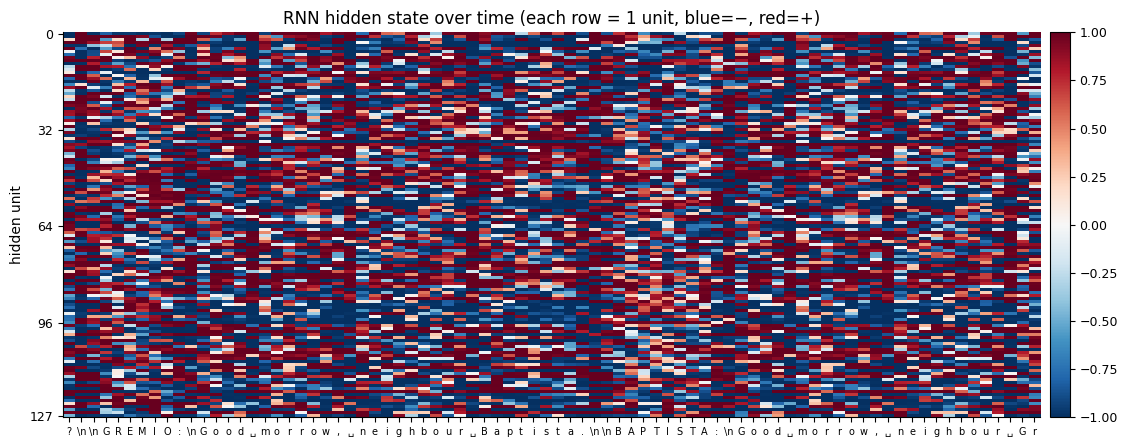

In [6]:
@torch.no_grad()
def hidden_trace(ids):
    h = torch.zeros(1, HIDDEN, device=device)
    trace = []
    for i in ids:
        x = emb[torch.tensor([i], device=device)]
        h = torch.tanh(x @ W_xh + h @ W_hh + b_h)
        trace.append(h.squeeze(0).cpu().numpy())
    return np.stack(trace, axis=1)  # (HIDDEN, T)

snippet_ids = val_data[:80].tolist()
H = hidden_trace(snippet_ids)

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(H, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(snippet_ids)))
ax.set_xticklabels([viz._printable(itos[i]) for i in snippet_ids], fontsize=7)
ax.set_yticks([0, 32, 64, 96, 127])
ax.set_ylabel("hidden unit")
ax.set_title("RNN hidden state over time (each row = 1 unit, blue=−, red=+)")
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
plt.show()


You can see bands of units switching sign on specific letters, like newlines — the RNN is clearly encoding *something* about the input. But notice that information about, say, the first character has to survive 80 matrix multiplications to influence the state at the end. That's the source of both problems below.

## Problem 1 — The sequential bottleneck

An RNN's forward pass for a length-$T$ sequence is a literal Python `for` loop of $T$ steps. Step `t+1` can't start until step `t` finishes — that's the definition of a recurrence. On a GPU that's devastating: you have thousands of cores sitting idle while one core computes one timestep.

Let's *measure* it. We'll time the RNN on sequences of increasing length. Because each step is serial, we expect roughly **linear** scaling with sequence length.


T=   32  forward    0.76 ms
T=   64  forward    1.43 ms
T=  128  forward    3.10 ms
T=  256  forward    5.93 ms
T=  512  forward   11.55 ms
T= 1024  forward   24.20 ms


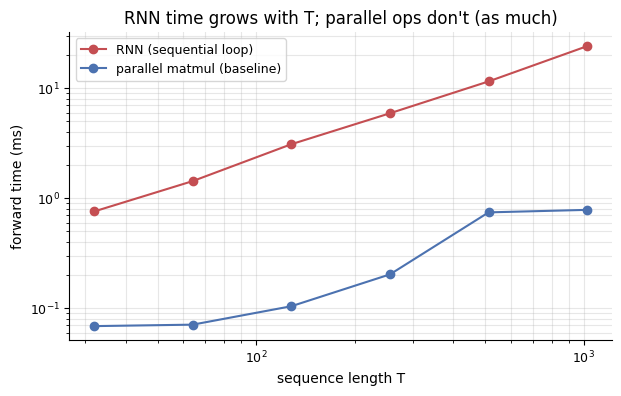

In [7]:
lengths = [32, 64, 128, 256, 512, 1024]
times_rnn = []
with torch.no_grad():
    for T in lengths:
        xb = torch.randint(0, vocab_size, (8, T), device=device)
        # warmup
        rnn_forward(xb)
        if device == "cuda": torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(3):
            rnn_forward(xb)
        if device == "cuda": torch.cuda.synchronize()
        times_rnn.append((time.time() - t0) / 3)

for T, dt in zip(lengths, times_rnn):
    print(f"T={T:5d}  forward {dt*1000:7.2f} ms")

# For contrast, we'll do the same timing for a trivial "parallel" op: one big
# matmul of roughly the same amount of work. This stands in for what attention
# looks like — one chunk of tensor math, no Python loop.
times_parallel = []
with torch.no_grad():
    for T in lengths:
        x = torch.randn(8, T, HIDDEN, device=device)
        M = torch.randn(HIDDEN, HIDDEN, device=device)
        if device == "cuda": torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(3):
            _ = x @ M
        if device == "cuda": torch.cuda.synchronize()
        times_parallel.append((time.time() - t0) / 3)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lengths, [t*1000 for t in times_rnn], "o-", label="RNN (sequential loop)", color="#C44E52")
ax.plot(lengths, [t*1000 for t in times_parallel], "o-", label="parallel matmul (baseline)", color="#4C72B0")
ax.set_xlabel("sequence length T"); ax.set_ylabel("forward time (ms)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_title("RNN time grows with T; parallel ops don't (as much)")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.show()


The RNN line slopes up steeply with sequence length. The parallel-matmul line — which, notably, *is* roughly the shape of what a transformer block does — slopes up much less. This is why, when you want to train on trillions of tokens, you do not use an RNN. The training-time tax is enormous.

## Problem 2 — Vanishing (and exploding) gradients

When you backprop through $T$ steps of $h_t = \tanh(W_{hh} h_{t-1} + \ldots)$, the gradient from position $T$ back to position $1$ goes through roughly $T$ multiplications by the Jacobian of each step. If the typical eigenvalue of that Jacobian is below 1, the gradient shrinks exponentially in $T$; if above 1, it explodes. Both are ruinous for learning long-range dependencies.

Let's see this directly. We'll run a forward pass of length $T$, take a loss at the *final* position, backprop, and look at how big the gradient is with respect to the hidden state at each earlier timestep.


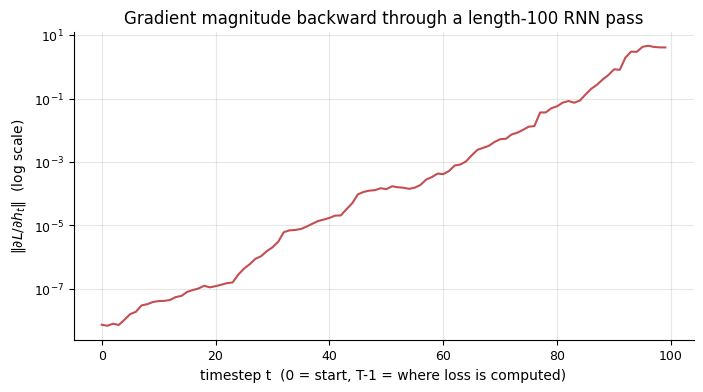

In [8]:
def grad_through_time(T=100, target_idx=0):
    # Compute ||dLoss_T / dh_t|| for every t, for a fresh RNN pass of length T.
    # Use a fresh random input so we isolate the architecture effect.
    xb = torch.randint(0, vocab_size, (1, T), device=device)
    x = emb[xb]                       # (1, T, EMB)
    h = torch.zeros(1, HIDDEN, device=device)
    hs = []
    for t in range(T):
        h = torch.tanh(x[:, t] @ W_xh + h @ W_hh + b_h)
        h.retain_grad()
        hs.append(h)
    # Loss at the final timestep only.
    logits = hs[-1] @ W_hy + b_y
    target = torch.tensor([target_idx], device=device)
    loss = F.cross_entropy(logits, target)
    # Zero existing grads on params so they don't accumulate here.
    for p in params:
        if p.grad is not None: p.grad = None
    loss.backward()
    norms = [ht.grad.norm().item() for ht in hs]
    return np.array(norms)

T = 100
norms = grad_through_time(T=T)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(T), norms, color="#C44E52")
ax.set_yscale("log")
ax.set_xlabel("timestep t  (0 = start, T-1 = where loss is computed)")
ax.set_ylabel(r"$\|\partial L / \partial h_t\|$  (log scale)")
ax.set_title(f"Gradient magnitude backward through a length-{T} RNN pass")
ax.grid(alpha=0.3, which="both")
plt.show()


Look at the left end of that plot. The gradient reaching the earliest timesteps is many orders of magnitude smaller than at the final timestep. That's the vanishing gradient problem in a single picture.

An RNN that literally can't feel the loss at distance 50 cannot learn structure at distance 50. Things like matching quotation marks, tracking who's speaking, remembering a name mentioned a paragraph ago — all of it gets increasingly hopeless as the distance grows.

LSTMs and GRUs help somewhat (with gates that make it easier to preserve information), but they don't fundamentally escape the sequential-bottleneck + diluted-signal combination.

## What we actually want

Taking stock, here's what we need from a better architecture:

1. **Direct connections between any two positions.** Position 200 should be able to look at position 3 in *one step*, not 197 matrix multiplications.
2. **Parallel training.** No Python `for` loop over sequence length. We want to compute the whole sequence's representations in one shot of tensor math.
3. **The model picks what to attend to.** We shouldn't hard-code that position $t$ cares about positions $t-3$ and $t-7$; the model should learn who to listen to.

All three are exactly what **self-attention** delivers. That's tomorrow night.

## Gut recap

- RNNs give you context but pay for it two ways: a sequential `for` loop (slow) and gradients that vanish through many recurrent steps (short effective memory).
- Even a heavily trained RNN struggles past a few dozen characters of context.
- We need an architecture where any position can reach any other position directly, and where the whole computation parallelizes.

**Next up:** [03 — Attention: the key idea →](03_attention_the_key_idea.ipynb)
